In [36]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, entropy
from scipy.spatial.distance import jensenshannon
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import scienceplots

plt.style.use(['science', 'ieee'])

In [37]:
def load_data(batch: list):
    df = pd.DataFrame()
    for cell in batch:
        cell = pd.read_csv(cell)
        df = pd.concat([df, cell], axis=0)
    # df.drop(columns=['RUL', 'SOH'], inplace=True)
    return df

def get_capacity(path):
    df = pd.read_csv(path)
    return df['SOH'].values

def plot_histogram_and_kde_all(df1, df2, df3, df4, stat_column=None):
    """
    所用的四个数据集的分布差异可视化
    """
    if stat_column is None:
        stat_columns = 'all'
        df1[stat_column] = df1.sum(axis=1)
        df2[stat_column] = df2.sum(axis=1)
        df3[stat_column] = df3.sum(axis=1)
        df4[stat_column] = df4.sum(axis=1)
    sns.kdeplot(df1[stat_column], color='r', fill=True, )
    sns.kdeplot(df2[stat_column], color='b', fill=True)
    sns.kdeplot(df3[stat_column], color='y', fill=True)
    sns.kdeplot(df4[stat_column], color='g', fill=True)
    plt.show()
    
def plot_histogram_and_kde_single(df1, df2, df3=None,
                                  soh1=None, soh2=None, soh3=None,
                                  stat_column=None, save_name=None,
                                  dataset_name=None):
    """
    统一坐标范围的分布与退化轨迹可视化
    - 退化轨迹的X轴基于最长循环数归一化
    - KDE分布的X轴对齐退化轨迹的最大X范围
    """
    single_width = 4  # 单图宽度（单位：英寸）
    single_height = single_width / 3  # 单图高度 = 总宽度/3
    
    plt.figure(figsize=(single_width, single_height))  # 关键尺寸调整
    
    # 确定最长退化轨迹的循环数
    soh_lengths = [len(soh) for soh in [soh1, soh2, soh3] if soh is not None]
    max_cycles = max(soh_lengths) if soh_lengths else 1  # 防除零
    
    # 处理stat_column为None的情况
    if stat_column is None:
        stat_column = 'temp_sum_column'
        df1[stat_column] = df1.sum(axis=1)
        df2[stat_column] = df2.sum(axis=1)
        if df3 is not None:
            df3[stat_column] = df3.sum(axis=1)
    
    # 通用归一化函数（映射到最长循环数范围）
    def scale_to_cycles(data, data_min, data_max):
        """将数据线性映射到[0, max_cycles]区间"""
        if data_max == data_min:
            return np.zeros_like(data)
        return (data - data_min) / (data_max - data_min) * max_cycles

    # 绘制KDE曲线（X轴对齐max_cycles）
    for idx, (df, color) in enumerate(zip([df1, df2, df3], ['r', 'b', 'y'])):
        if df is None:
            continue
        data = df[stat_column].values
        data_min, data_max = data.min(), data.max()
        
        # 生成KDE曲线
        kde = gaussian_kde(data)
        x_kde = np.linspace(data_min, data_max, 500)
        y_kde = kde(x_kde)
        
        # 将KDE的X轴映射到max_cycles范围并归一化
        x_scaled = scale_to_cycles(x_kde, data_min, data_max) / max_cycles
        y_normalized = (y_kde - y_kde.min()) / (y_kde.max() - y_kde.min())  # Y归一化
        
        plt.plot(x_scaled, y_normalized, color=color, ls='--', alpha=0.8)
        plt.fill_between(x_scaled, y_normalized, color=color, alpha=0.1)

        # 保存x_scaled, y_normalized到csv文件
        save_path = f"{dataset_name}_kde_data_{idx}.csv"
        save_index = np.arange(1, len(x_scaled) + 1)
        kde_data = {
            'X_scaled': x_scaled,
            'Y_normalized': y_normalized
        }
        df_kde = pd.DataFrame(kde_data)
        df_kde.to_csv(save_path, index=False)

    # 绘制退化轨迹（保留长度比例）
    for idx, (soh, color) in enumerate(zip([soh1, soh2, soh3], ['r', 'b', 'y'])):
        if soh is None:
            continue
        soh_data = np.asarray(soh)
        cycles = len(soh_data)
        
        # X轴：实际循环数 / max_cycles，Y轴归一化
        x = np.arange(cycles) / max_cycles
        y_normalized = (soh_data - soh_data.min()) / (soh_data.ptp() if soh_data.ptp() !=0 else 1)
        
        plt.plot(x, y_normalized, color=color, markersize=4, alpha=0.6)

        save_path = f"{dataset_name}_soh_data_{idx}.csv"
        # save_index = np.arange(1, len(soh_data) + 1)
        soh_data = {
            'Cycle': x,
            'SOH': y_normalized
        }
        df_soh = pd.DataFrame(soh_data)
        df_soh.to_csv(save_path, index=False)

    # 坐标轴标注
    # plt.xlabel("Normalized Cycle Number (by Max Cycles)", fontsize=12)
    # plt.ylabel("Normalized Value", fontsize=12)
    # plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks([])  # 移除X轴刻度
    plt.yticks([])  # 移除Y轴刻度
    
    if save_name:
        plt.savefig(save_name, bbox_inches='tight', dpi=300)
    plt.show()

In [38]:
# matr_paths = glob.glob(os.path.join('../../data/dataset/tri/pseudo', '*.csv'))
# tongji_paths = glob.glob(os.path.join('../../data/dataset/tongji/nca', '*.csv'))
# hust_paths = glob.glob(os.path.join('../../data/dataset/hust/pseudo', '*.csv'))
# xjtu_paths = glob.glob(os.path.join('../../data/dataset/xjtu/pseudo', '*.csv'))

# matr_df = load_data(matr_paths)
# tongji_df = load_data(tongji_paths)
# hust_df = load_data(hust_paths)
# xjtu_df = load_data(xjtu_paths)

# plot_histogram_and_kde_all(matr_df, tongji_df, hust_df, xjtu_df)

- 电极材料导致的分布漂移（tongji dataset）
- 充电协议的差异导致的分布漂移（mit dataset）
- 放电深度差异导致的分布漂移（xjtu dataset，3C-xxx和R3-xxx）

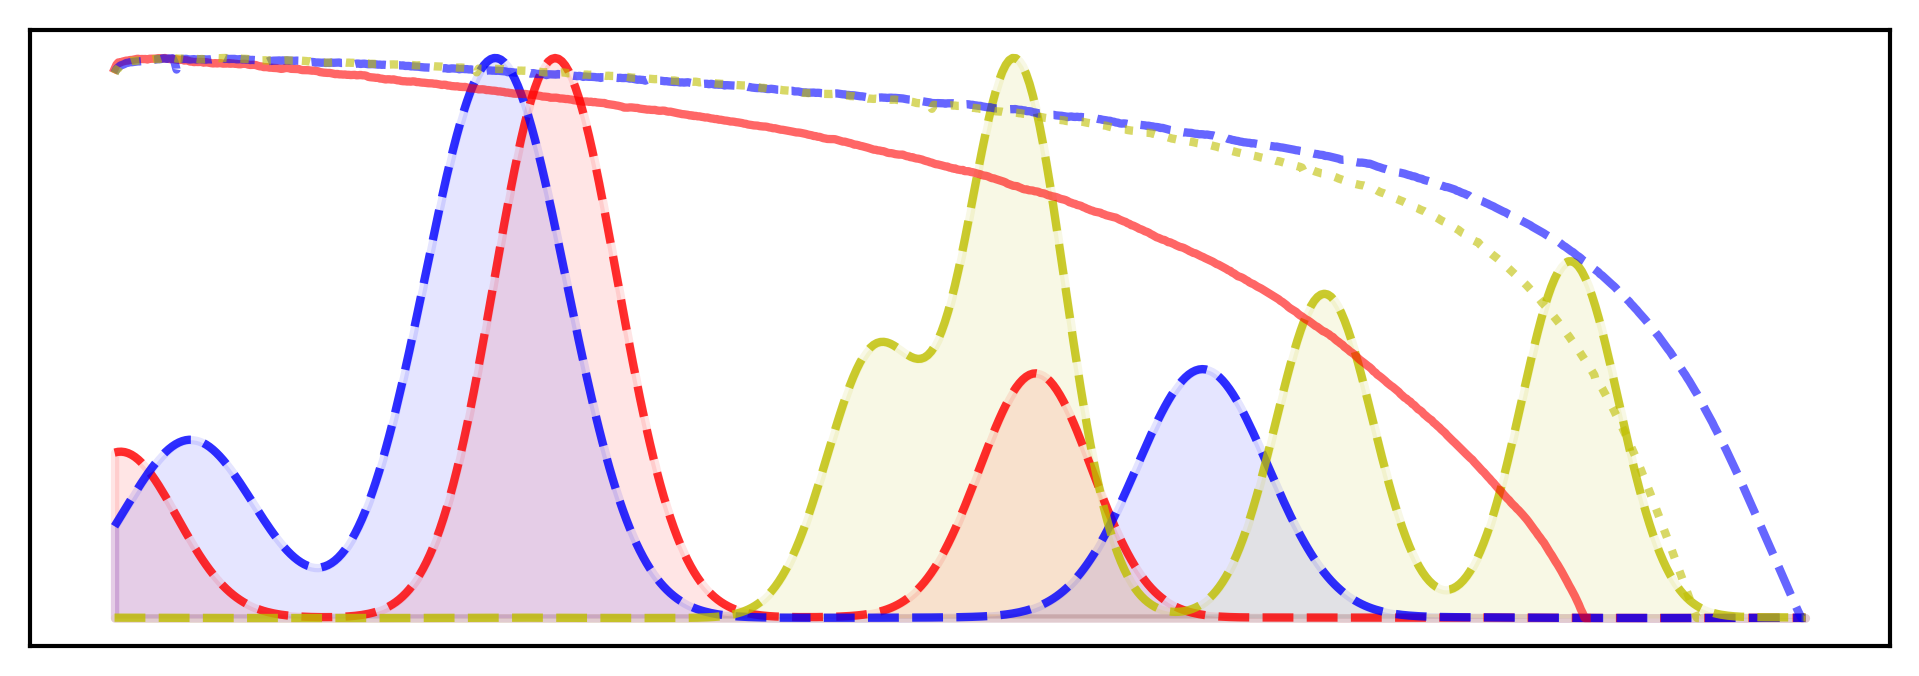

In [39]:
charge_protocol_1 = glob.glob(os.path.join('../../data/dataset/mit/pseudo', '3.6*.csv'))
charge_protocol_2 = glob.glob(os.path.join('../../data/dataset/mit/pseudo', '4.8*.csv'))
charge_protocol_3 = glob.glob(os.path.join('../../data/dataset/mit/pseudo', '6*.csv'))

charge_protocol_1_df = load_data(charge_protocol_1)
charge_protocol_2_df = load_data(charge_protocol_2)
charge_protocol_3_df = load_data(charge_protocol_3)

charge_protocol_1_soh = get_capacity(charge_protocol_1[0])
charge_protocol_2_soh = get_capacity(charge_protocol_2[0])
charge_protocol_3_soh = get_capacity(charge_protocol_3[0])

plot_histogram_and_kde_single(charge_protocol_1_df,
                              charge_protocol_2_df,
                              charge_protocol_3_df,
                              soh1=charge_protocol_1_soh,
                              soh2=charge_protocol_2_soh,
                              soh3=charge_protocol_3_soh,
                              save_name='./fig1_challenges_subfig21.png',
                              dataset_name='MIT',)

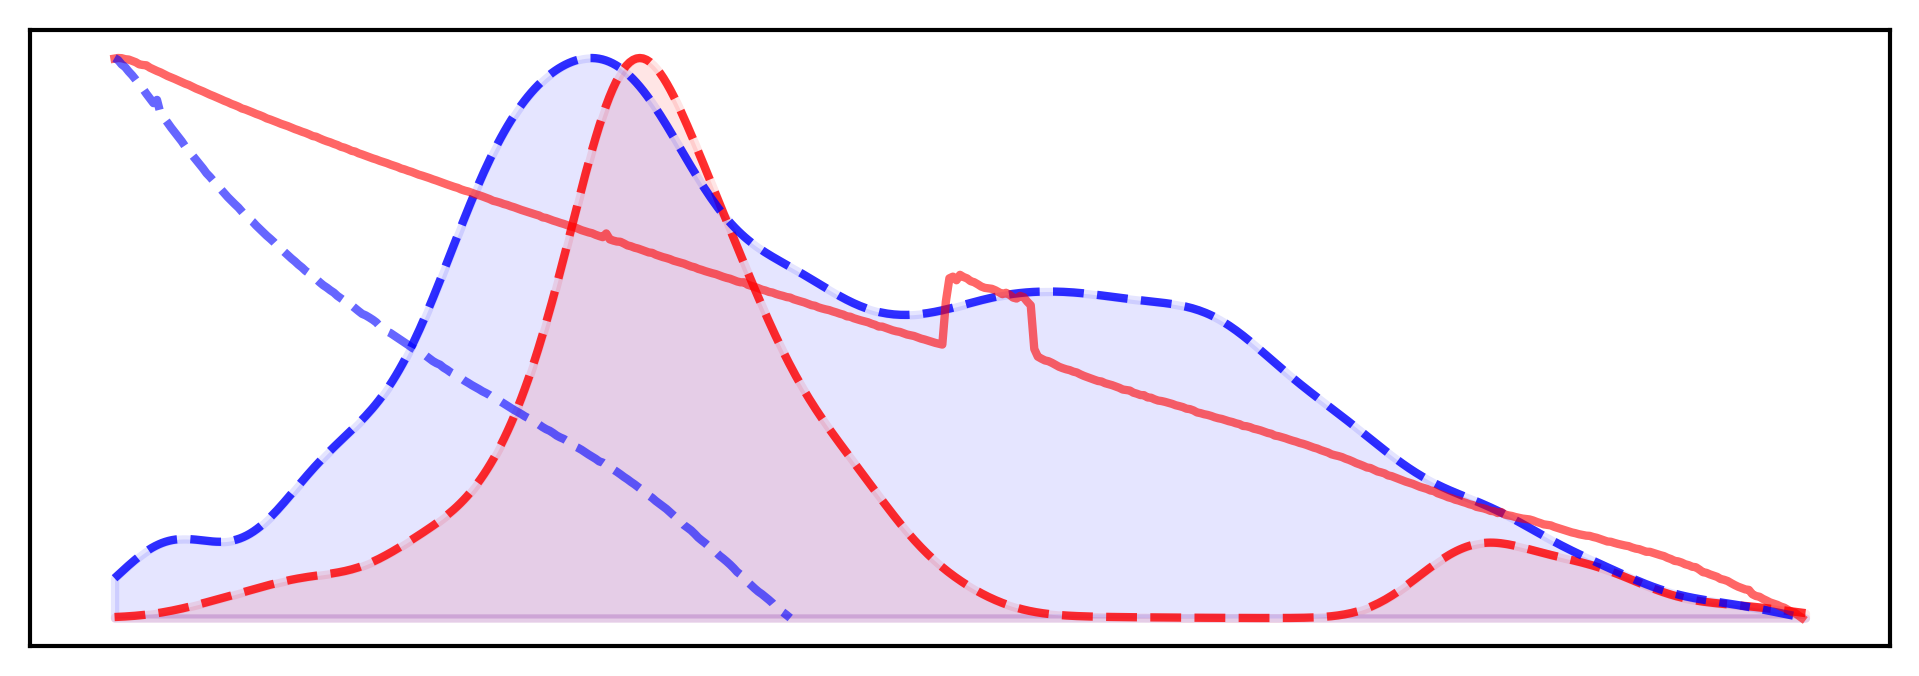

In [40]:
material_nca = glob.glob(os.path.join('../../data/dataset/tongji/nca', '*.csv'))
material_ncm = glob.glob(os.path.join('../../data/dataset/tongji/ncm', '*.csv'))

material_nca_df = load_data(material_nca)
material_ncm_df = load_data(material_ncm)

material_nca_soh = get_capacity(material_nca[0])
material_ncm_soh = get_capacity(material_ncm[0])

plot_histogram_and_kde_single(material_nca_df,
                              material_ncm_df,
                              soh1=material_nca_soh,
                              soh2=material_ncm_soh,
                              save_name='./fig1_challenges_subfig22.png',
                              dataset_name='Tongji',)

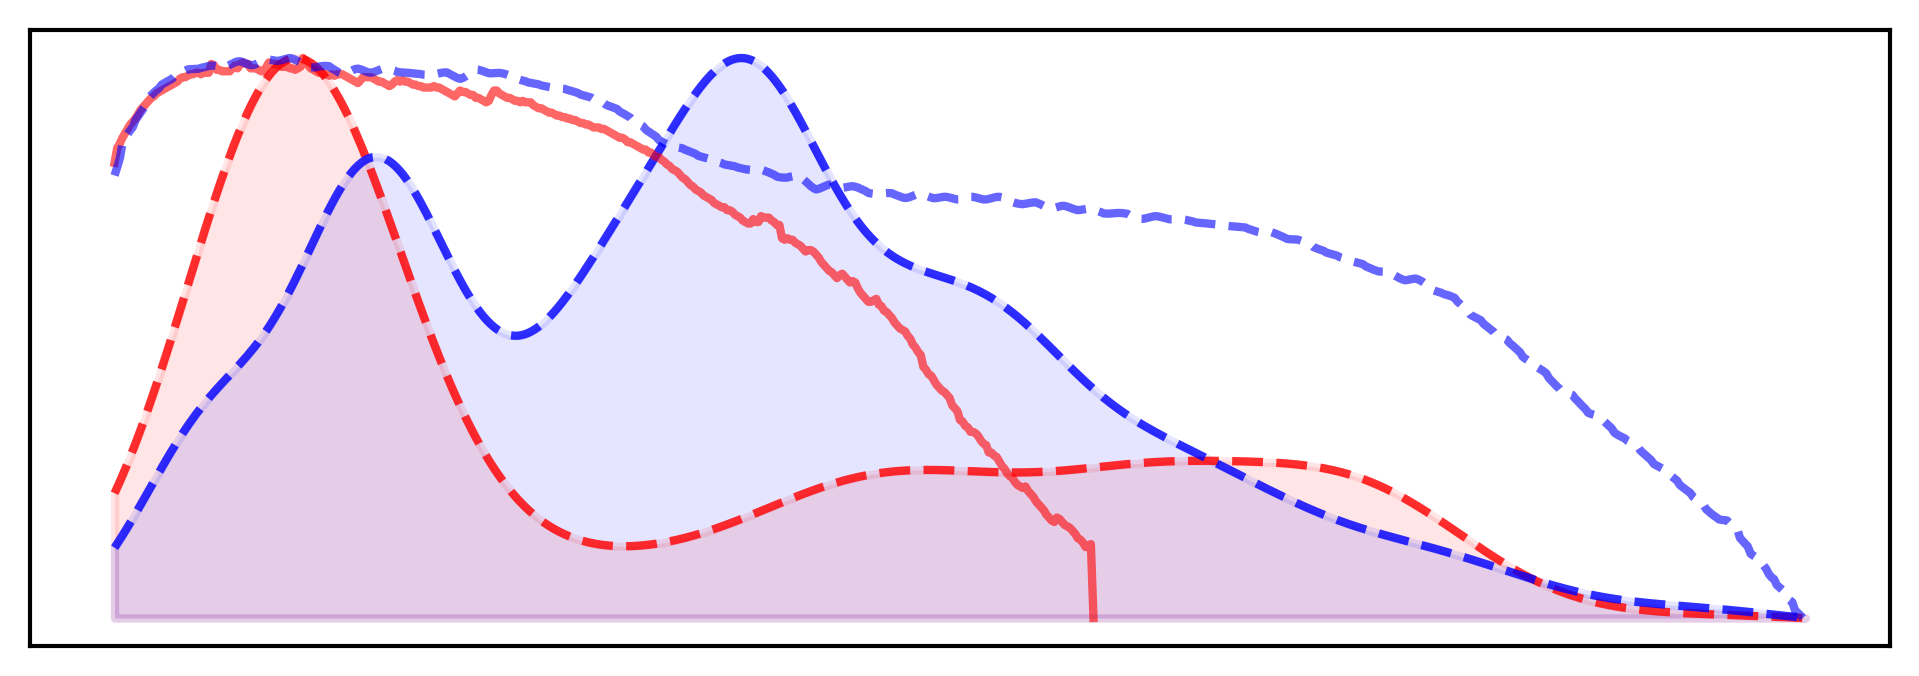

In [41]:
dod_1 = glob.glob(os.path.join('../../data/dataset/xjtu/pseudo', '2C*.csv'))
dod_2 = glob.glob(os.path.join('../../data/dataset/xjtu/pseudo', 'R3*.csv'))

dod_1_df = load_data(dod_1)
dod_2_df = load_data(dod_2)

dod_1_soh = get_capacity(dod_1[0])
dod_2_soh = get_capacity(dod_2[0])

plot_histogram_and_kde_single(dod_1_df,
                              dod_2_df,
                              soh1=dod_1_soh,
                              soh2=dod_2_soh,
                              save_name='./fig1_challenges_subfig23.png',
                              dataset_name='XJTU',)

## 子图拼接示例

In [42]:
# from PIL import Image
# import numpy as np

# # 输入文件列表（按顺序排列）
# image_paths = [
#     "./fig1_challenges_subfig21.png",
#     "./fig1_challenges_subfig22.png",
#     "./fig1_challenges_subfig23.png"
# ]

# # 读取所有图片对象
# images = [Image.open(path) for path in image_paths]

# # 统一宽度（以最窄图片的宽度为基准）
# min_width = min(img.width for img in images)

# # 按原始比例调整高度（保持宽高比）
# resized_images = []
# for img in images:
#     width_percent = min_width / float(img.width)
#     new_height = int(float(img.height) * width_percent)
#     resized_img = img.resize((min_width, new_height), Image.Resampling.LANCZOS)
#     resized_images.append(resized_img)

# # 计算总高度
# total_height = sum(img.height for img in resized_images)

# # 创建纯白背景画布（宽度统一，高度为各图之和）
# canvas = Image.new("RGB", (min_width, total_height), (255, 255, 255))

# # 纵向拼接（不留间隙）
# y_offset = 0
# for img in resized_images:
#     canvas.paste(img, (0, y_offset))
#     y_offset += img.height  # 直接累加高度，不留间隙

# # 保存结果（无损PNG格式）
# canvas.save("./combined_result.png", format="PNG", dpi=(300, 300))